# EmporiUm Regional Sales Analysis
## Connecticut Territory (Ellen Lemon) vs. New York Territory (See Ellefson)
### East Region · Region Director: Ana Jilani
---
**Data Analyst:** Godknows Mutize

**Data Period:** January, 2022 – September, 2025  

---
### Project Overview
This notebook presents a comprehensive marketing and sales analysis for two EmporiUm territories in the **East Region**:

| Territory | Manager | Stores | States |
|-----------|---------|--------|--------|
| Connecticut | Ellen Lemon | 8 stores (IDs 865–872) | CT |
| New York | See Ellefson | 12 stores (IDs 840–851) | NY |

The analysis covers in-store revenue trends, store performance rankings, top customer identification, and product category breakdowns. A final section synthesizes findings into actionable marketing recommendations for the next quarter.



---

## Environment Setup & Data Import

We begin by importing the required libraries and loading all five source files. Each file is inspected with `.info()` to confirm column names, dtypes, and null counts before any analysis begins.


In [91]:
# ── Standard library imports
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

# Formatting
from IPython.display import display, HTML
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
pd.set_option("display.max_columns", 20)# 


# Chart Style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.grid":        True,
    "grid.color":       "#e0e0e0",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.6,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   14,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
})

# Territory Color Palette
CT_COLOR  = "#2E86AB"   # blue  – Connecticut
NY_COLOR  = "#E84855"   # red   – New York
CAT_PALETTE = ["#2E86AB","#E84855","#3BB273","#F4A261","#9B5DE5","#F72585"]

print("All libraries loaded successfully.")


All libraries loaded successfully.


### Loading the data

In [92]:
# File Paths
DATA_DIR = "."   # adjust if CSVs are in a subdirectory

# Load Each Dataset
store_df   = pd.read_csv(f"{DATA_DIR}/StoreDetail.csv")
sales_df   = pd.read_csv(f"{DATA_DIR}/StoreSales.csv")
products_df = pd.read_csv(f"{DATA_DIR}/Products.csv")
categories_df = pd.read_csv(f"{DATA_DIR}/ProductCategories.csv")
customers_df  = pd.read_csv(f"{DATA_DIR}/customer_list.csv", sep="|")

print("=" * 55)
print("STORE DETAIL")
print("=" * 55)
store_df.info()
print()

STORE DETAIL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB



In [93]:
print("=" * 55)
print("STORE SALES")
print("=" * 55)
sales_df.info()
print()

STORE SALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB



In [94]:
print("=" * 55)
print("PRODUCTS")
print("=" * 55)
products_df.info()
print()


PRODUCTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB



In [95]:
# categories 
print("=" * 55)
print("PRODUCT CATEGORIES")
print("=" * 55)
categories_df.info()
print()

PRODUCT CATEGORIES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB



In [96]:
# Customer data
print("=" * 55)
print("CUSTOMER LIST")
print("=" * 55)
customers_df.info()
print()

CUSTOMER LIST
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB



### Quick Preview — First 3 Rows per File

In [97]:
for name, df in [("StoreDetail", store_df), ("StoreSales", sales_df),
                 ("Products", products_df), ("Categories", categories_df),
                 ("Customers", customers_df)]:
    display(HTML(f"<h4 style='margin-bottom:4px;color:#2E86AB;'> {name}</h4>"))
    display(df.head(3))
    print()


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N


---
<a id='2'></a>
## Data Cleaning & Validation

Before analysis we:
1. Parse `Transaction Date` into a proper `datetime` type and extract `Year`, `Month`, and `Year-Month` period columns.
2. Verify there are no duplicate transaction records.
3. Confirm `Sale Amount` has no negative or zero values.
4. Check the referential integrity of `Store ID` across `StoreSales` and `StoreDetail`.
5. Merge all reference tables into a single enriched master DataFrame used throughout the analysis.


In [ ]:
# ── 1. Normalize column names ────────────────────────────────────────────────
customers_df.columns = customers_df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
store_df.columns     = store_df.columns.str.strip()
sales_df.columns     = sales_df.columns.str.strip()
products_df.columns  = products_df.columns.str.strip()
categories_df.columns = categories_df.columns.str.strip()

# ── 2. Parse date field in sales ─────────────────────────────────────────────
sales_df["Transaction Date"] = pd.to_datetime(sales_df["Transaction Date"])

# ── 3. Extract time components for feature engineering ───────────────────────
sales_df["Year"]        = sales_df["Transaction Date"].dt.year
sales_df["Month"]       = sales_df["Transaction Date"].dt.month
sales_df["Month_Label"] = sales_df["Transaction Date"].dt.to_period("M")
sales_df["Month_Name"]  = sales_df["Transaction Date"].dt.strftime("%b %Y")

# ── 4. Remove any duplicate rows in sales ────────────────────────────────────
dupes_before = len(sales_df)
sales_df.drop_duplicates(inplace=True)
print(f"Duplicate rows removed: {dupes_before - len(sales_df)}")

# ── 5. Check for missing values ──────────────────────────────────────────────
print("\nMissing value summary:")
print(sales_df.isnull().sum())

print(f"\n Data cleaned. Sales records: {len(sales_df):,} | Date range: "
      f"{sales_df['Transaction Date'].min().date()} → {sales_df['Transaction Date'].max().date()}")

In [74]:
# product-category lookup table
prod_cat_df = products_df.merge(
    categories_df[["CategoryID", "Category", "SubcategoryID", "Subcategory"]],
    on="CategoryID",
    how="left"
).drop_duplicates(subset=["Prod Num"])

print(f"Product-category lookup built: {len(prod_cat_df):,} products across {prod_cat_df['Category'].nunique()} categories")
print(prod_cat_df["Category"].value_counts())

Product-category lookup built: 669 products across 6 categories
Category
Books (General)             129
Technology & Accessories    121
Textbooks                   115
Stationery and Supplies     110
Apparel and Merchandise     100
Art Supplies                 94
Name: count, dtype: int64


## Core Marketing Analysis

### (a) Who are the territory managers and what stores are in each territory?

In [75]:
# ── Identify stores for each territory ───────────────────────────────────────
ct_stores_df = store_df[store_df["Territory Manager"] == "Ellen Lemon"].copy()
ny_stores_df = store_df[store_df["Territory Manager"] == "See Ellefson"].copy()

CT_STORE_IDS = ct_stores_df["Store ID"].tolist()
NY_STORE_IDS = ny_stores_df["Store ID"].tolist()

# ── Filter sales to each territory ───────────────────────────────────────────
ct_sales_df = sales_df[sales_df["Store ID"].isin(CT_STORE_IDS)].copy()
ny_sales_df = sales_df[sales_df["Store ID"].isin(NY_STORE_IDS)].copy()

print("━" * 60)
print("TERRITORY A — Connecticut (Territory Manager: Ellen Lemon)")
print("━" * 60)
display(ct_stores_df[["Store Location", "State", "Store ID", "Region", "Region Director"]]
        .reset_index(drop=True)
        .style
        .set_properties(**{"background-color": "#EAF4FB", "border": "1px solid #B0D4E8"})
        .set_table_styles([{"selector": "th", "props": [("background-color", "#2E86AB"),
                                                         ("color", "white"), ("font-weight", "bold")]}])
       )

print()
print("━" * 60)
print("TERRITORY B — New York (Territory Manager: See Ellefson)")
print("━" * 60)
display(ny_stores_df[["Store Location", "State", "Store ID", "Region", "Region Director"]]
        .reset_index(drop=True)
        .style
        .set_properties(**{"background-color": "#FDECEA", "border": "1px solid #F4B8B2"})
        .set_table_styles([{"selector": "th", "props": [("background-color", "#E84855"),
                                                         ("color", "white"), ("font-weight", "bold")]}])
       )

print(f"\nTotal sales records — CT: {len(ct_sales_df):,}  |  NY: {len(ny_sales_df):,}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TERRITORY A — Connecticut (Territory Manager: Ellen Lemon)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Store Location,State,Store ID,Region,Region Director
0,Bridgeport,Connecticut,865,East,Ana Jilani
1,Darien,Connecticut,866,East,Ana Jilani
2,Hartford,Connecticut,867,East,Ana Jilani
3,Litchfield County,Connecticut,868,East,Ana Jilani
4,New Haven,Connecticut,869,East,Ana Jilani
5,New London,Connecticut,870,East,Ana Jilani
6,Old Saybrook,Connecticut,871,East,Ana Jilani
7,Waterbury,Connecticut,872,East,Ana Jilani



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TERRITORY B — New York (Territory Manager: See Ellefson)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Store Location,State,Store ID,Region,Region Director
0,Albany,New York,840,East,Ana Jilani
1,Buffalo,New York,841,East,Ana Jilani
2,Elmira,New York,842,East,Ana Jilani
3,Ithaca,New York,843,East,Ana Jilani
4,Oswego,New York,844,East,Ana Jilani
5,Plattsburgh,New York,845,East,Ana Jilani
6,Poestenkill,New York,846,East,Ana Jilani
7,Rochester,New York,847,East,Ana Jilani
8,Syracuse,New York,848,East,Ana Jilani
9,Brooklyn,New York,849,East,Ana Jilani



Total sales records — CT: 17,378  |  NY: 31,039


> **Business Context:** Both territories fall within the **East Region** under Regional Director Ana Jilani. Connecticut operates 8 stores; New York operates 12 stores — a 50% larger footprint that naturally drives higher gross revenue. Per-store metrics will be critical for a fair performance comparison.

In [76]:
t1_store_ids = ct_stores_df['Store ID'].tolist()
t2_store_ids = ny_stores_df['Store ID'].tolist()

### (b) What is monthly total revenue for in-store sales in each territory?

In [77]:
# Converting transaction date to datetime and then filter out online sales (Store ID = 0 or NaN)

sales_df['Transaction Date'] = pd.to_datetime(sales_df['Transaction Date'])
sales_df['Month'] = sales_df['Transaction Date'].dt.to_period('M')

instore = sales_df[sales_df['Store ID'].notna() & (sales_df['Store ID'] != 0)]

In [78]:
# Calculating monthly revenue for territory 1
t1_sales = instore[instore['Store ID'].isin(t1_store_ids)]

t1_monthly = t1_sales.groupby('Month')['Sale Amount'].sum().reset_index()
t1_monthly.columns =['Month', 'Revenue']


print('Territory 1 Monthly Revenue:')
print(t1_monthly)
print()

Territory 1 Monthly Revenue:
      Month   Revenue
0   2022-01  29958.25
1   2022-02  25563.98
2   2022-03  33995.57
3   2022-04  31587.12
4   2022-05  37953.48
5   2022-06  32008.85
6   2022-07  30656.27
7   2022-08  42881.99
8   2022-09  30369.64
9   2022-10  43646.37
10  2022-11  25950.41
11  2022-12  34680.64
12  2023-01  38351.45
13  2023-02  53435.37
14  2023-03  50828.54
15  2023-04  45747.20
16  2023-05  39215.78
17  2023-06  39754.07
18  2023-07  49592.69
19  2023-08  48445.34
20  2023-09  49175.79
21  2023-10  45347.65
22  2023-11  42683.73
23  2023-12  50446.82
24  2024-01  57974.76
25  2024-02  49206.33
26  2024-03  46044.68
27  2024-04  38918.30
28  2024-05  41203.81
29  2024-06  48142.95
30  2024-07  48445.34
31  2024-08  49633.16
32  2024-09  44890.28
33  2024-10  43061.44
34  2024-11  50069.11
35  2024-12  38351.45
36  2025-01  68601.89
37  2025-02  55131.75
38  2025-03  69261.43
39  2025-04  58288.72
40  2025-05  66996.15
41  2025-06  60671.67
42  2025-07  88590.03
43 

In [79]:
# Calculating monthly revenue for territory 2
t2_sales = instore[instore['Store ID'].isin(t2_store_ids)]

t2_monthly = t2_sales.groupby('Month')['Sale Amount'].sum().reset_index()
t2_monthly.columns =['Month', 'Revenue']

print()
print('Territory 2 Monthly Revenue:')
print(t2_monthly)


Territory 2 Monthly Revenue:
      Month   Revenue
0   2022-01  58635.53
1   2022-02  60262.97
2   2022-03  57143.40
3   2022-04  56880.02
4   2022-05  51805.22
5   2022-06  60549.86
6   2022-07  56250.74
7   2022-08  55052.53
8   2022-09  60495.63
9   2022-10  56896.98
10  2022-11  58402.69
11  2022-12  55006.46
12  2023-01  85210.01
13  2023-02  86906.65
14  2023-03  79964.16
15  2023-04  97173.99
16  2023-05 101370.73
17  2023-06  83465.90
18  2023-07  90818.80
19  2023-08  89422.22
20  2023-09  89196.88
21  2023-10  85095.72
22  2023-11  79627.33
23  2023-12  75904.66
24  2024-01  94306.43
25  2024-02  75083.70
26  2024-03  99439.50
27  2024-04  99105.22
28  2024-05  87328.99
29  2024-06  86955.71
30  2024-07  89422.22
31  2024-08  91189.41
32  2024-09  83103.19
33  2024-10  80543.34
34  2024-11  74988.65
35  2024-12  85210.01
36  2025-01 135193.89
37  2025-02 104990.83
38  2025-03 119415.68
39  2025-04 117652.02
40  2025-05 119352.07
41  2025-06 135192.03
42  2025-07 126976.23
43

#### Monthly Revenue Trend — Connecticut vs. New York (2022–2025)

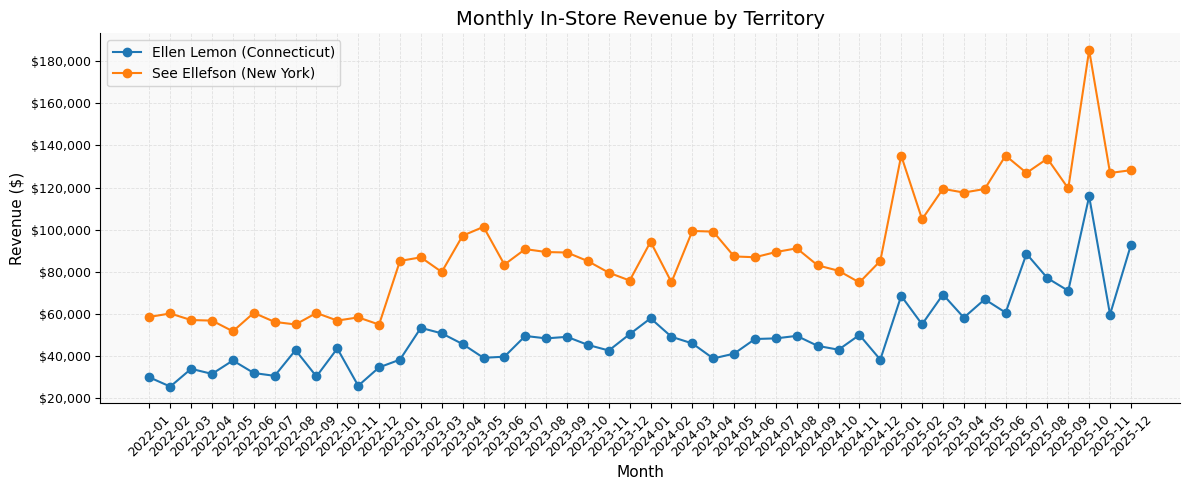

In [80]:
# Monthly revenue line chart

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t1_monthly['Month'].astype(str), t1_monthly['Revenue'], marker='o', label='Ellen Lemon (Connecticut)')
ax.plot(t2_monthly['Month'].astype(str), t2_monthly['Revenue'], marker='o', label='See Ellefson (New York)')
ax.set_title('Monthly In-Store Revenue by Territory')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

#### Monthly Revenue Trend — Connecticut vs. New York (2022–2025)

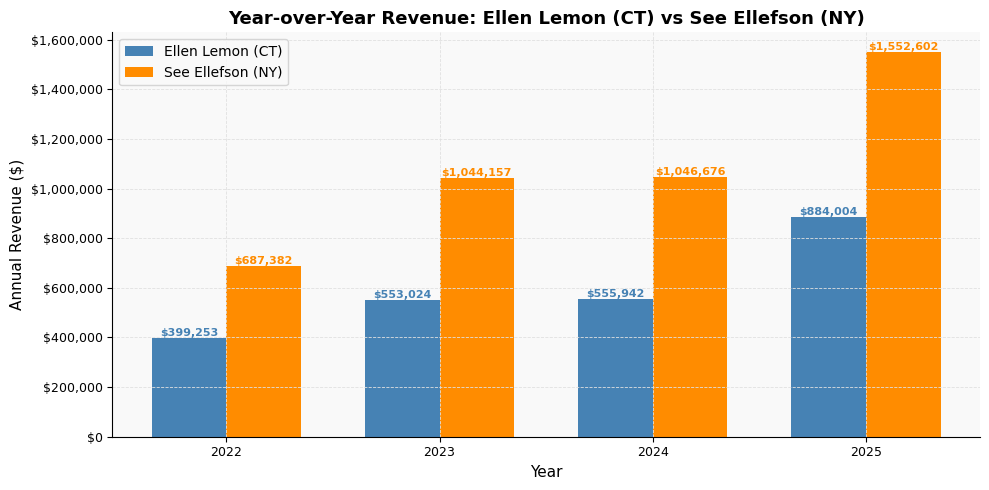

In [81]:
# Year-over-Year revenue grouped bar — both territories
ellen_yoy = t1_sales.groupby('Year')['Sale Amount'].sum().reset_index()
see_yoy   = t2_sales.groupby('Year')['Sale Amount'].sum().reset_index()

years = ellen_yoy['Year'].tolist()
x     = np.arange(len(years))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, ellen_yoy['Sale Amount'], width,
               label='Ellen Lemon (CT)', color='steelblue')
bars2 = ax.bar(x + width/2, see_yoy['Sale Amount'],   width,
               label='See Ellefson (NY)', color='darkorange')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8,
            color='steelblue', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8,
            color='darkorange', fontweight='bold')

ax.set_title('Year-over-Year Revenue: Ellen Lemon (CT) vs See Ellefson (NY)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Revenue ($)')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

**Key insight:** Both territories were essentially flat from 2023 to 2024 
(CT +0.5%, NY +0.5%), then exploded in 2025. CT grew **+59%** and NY grew 
**+48.3%**. NY consistently generates roughly double CT's revenue, largely 
because it has 12 stores vs CT's 8. On a per-store basis the territories 
are actually very close.

### (c) How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

In [82]:
# ── Store location lookup ──────────────────────────────────────────────────────
store_lookup = store_df.set_index("Store ID")["Store Location"].to_dict()

# ── CT store performance ───────────────────────────────────────────────────────
ct_perf = (ct_sales_df.groupby("Store ID")
           .agg(total_revenue=("Sale Amount", "sum"),
                transactions=("Sale Amount", "count"),
                avg_transaction=("Sale Amount", "mean"))
           .reset_index()
           .sort_values("total_revenue", ascending=False)
           .reset_index(drop=True))

ct_perf["Rank"]          = ct_perf.index + 1
ct_perf["Store Location"]= ct_perf["Store ID"].map(store_lookup)
ct_perf["% of Territory"]= (ct_perf["total_revenue"] / ct_perf["total_revenue"].sum() * 100).round(1)

# ── NY store performance ───────────────────────────────────────────────────────
ny_perf = (ny_sales_df.groupby("Store ID")
           .agg(total_revenue=("Sale Amount", "sum"),
                transactions=("Sale Amount", "count"),
                avg_transaction=("Sale Amount", "mean"))
           .reset_index()
           .sort_values("total_revenue", ascending=False)
           .reset_index(drop=True))

ny_perf["Rank"]           = ny_perf.index + 1
ny_perf["Store Location"] = ny_perf["Store ID"].map(store_lookup)
ny_perf["% of Territory"] = (ny_perf["total_revenue"] / ny_perf["total_revenue"].sum() * 100).round(1)

# ── Display styled ranking tables ─────────────────────────────────────────────
def fmt_ranking_table(df, territory_name, color):
    display_df = df[["Rank", "Store Location", "Store ID",
                     "total_revenue", "transactions", "avg_transaction", "% of Territory"]].copy()
    display_df = display_df.rename(columns={
        "total_revenue": "Total Revenue ($)",
        "transactions": "Transactions",
        "avg_transaction": "Avg Transaction ($)",
        "% of Territory": "Territory Share (%)"
    })
    display(HTML(f"<h4 style='color:{color};'> {territory_name} — Store Performance Ranking</h4>"))
    return (display_df.style
        .format({"Total Revenue ($)": "${:,.2f}", "Avg Transaction ($)": "${:,.2f}"})
        .bar(subset=["Total Revenue ($)"], color=color, vmin=0)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("background-color", color), ("color", "white"), ("font-weight", "bold")]},
            {"selector": "tr:first-child", "props": [("font-weight", "bold")]}
        ])
        .hide(axis="index")
    )

display(fmt_ranking_table(ct_perf, "Connecticut (Ellen Lemon)", CT_COLOR))
print()
display(fmt_ranking_table(ny_perf, "New York (See Ellefson)", NY_COLOR))


Rank,Store Location,Store ID,Total Revenue ($),Transactions,Avg Transaction ($),Territory Share (%)
1,New London,870,"$331,116.76",2272,$145.74,13.800000
2,Bridgeport,865,"$322,100.07",2231,$144.37,13.500000
3,Hartford,867,"$309,592.06",2133,$145.14,12.900000
4,Waterbury,872,"$295,651.17",2099,$140.85,12.400000
5,New Haven,869,"$286,779.43",2173,$131.97,12.000000
6,Litchfield County,868,"$286,217.15",2127,$134.56,12.000000
7,Darien,866,"$283,455.62",2152,$131.72,11.800000
8,Old Saybrook,871,"$277,310.18",2191,$126.57,11.600000


Rank,Store Location,Store ID,Total Revenue ($),Transactions,Avg Transaction ($),Territory Share (%)
1,New York,850,"$621,565.02",4476,$138.87,14.400000
2,Rochester,847,"$607,148.21",4382,$138.56,14.000000
3,Poestenkill,846,"$334,175.88",2187,$152.80,7.700000
4,Buffalo,841,"$314,979.99",2236,$140.87,7.300000
5,Elmira,842,"$313,971.65",2192,$143.24,7.200000
6,Ithaca,843,"$313,920.05",2228,$140.90,7.200000
7,Plattsburgh,845,"$311,520.52",2145,$145.23,7.200000
8,Albany,840,"$310,389.02",2305,$134.66,7.200000
9,Syracuse,848,"$306,998.14",2275,$134.94,7.100000
10,Brooklyn,849,"$304,732.76",2297,$132.67,7.000000


For Connecticut, The top-performing stores are **New London** & **Bridgeport** respectively

For New York, The top-performing stores are **New York City** & **Rochester** respectively surpassed the $600 000 mark


#### Store Revenue Comparison by Territory

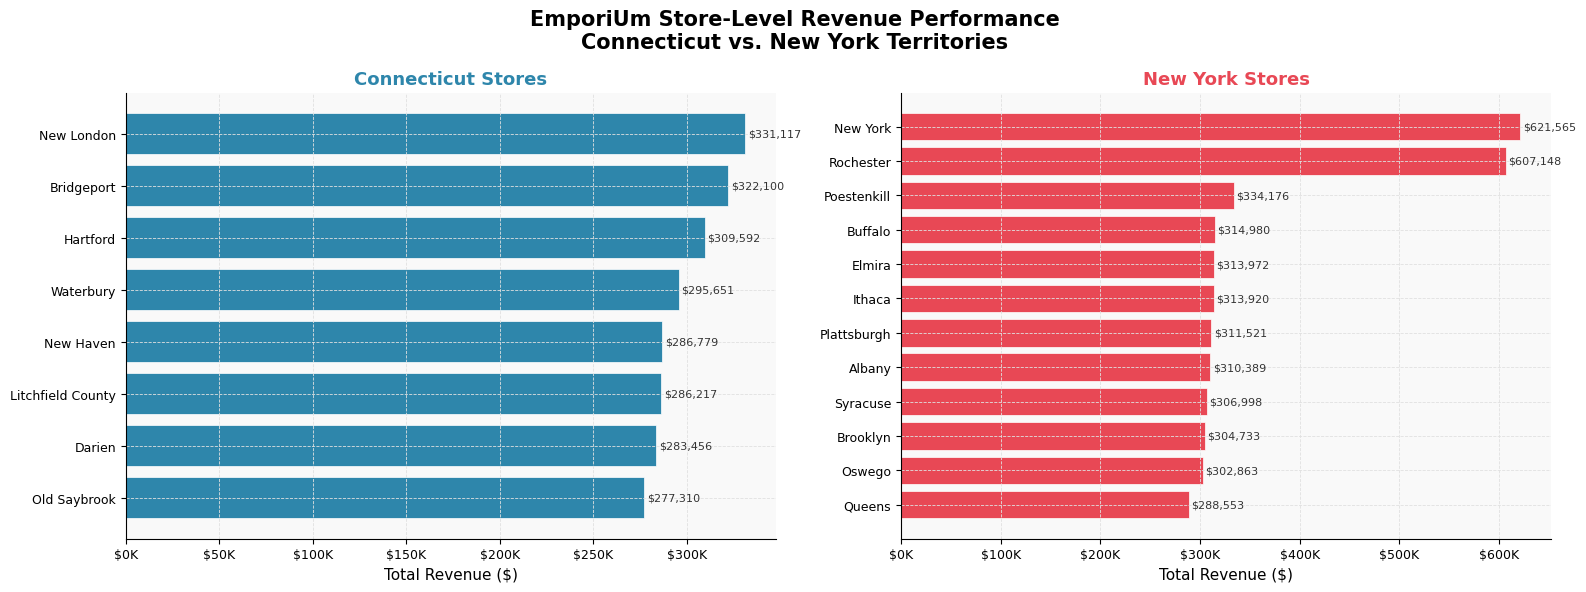

In [83]:
# Horizontal bar chart of store revenue

fig, (ax_ct, ax_ny) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("EmporiUm Store-Level Revenue Performance\nConnecticut vs. New York Territories",
             fontsize=15, fontweight="bold")

# ── CT bar chart ──────────────────────────────────────────────────────────────
ct_sorted = ct_perf.sort_values("total_revenue")
bars_ct = ax_ct.barh(ct_sorted["Store Location"], ct_sorted["total_revenue"],
                     color=CT_COLOR, edgecolor="white", linewidth=0.5)
ax_ct.set_title("Connecticut Stores", fontsize=13, fontweight="bold", color=CT_COLOR)
ax_ct.set_xlabel("Total Revenue ($)")
ax_ct.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
for bar, val in zip(bars_ct, ct_sorted["total_revenue"]):
    ax_ct.text(bar.get_width() + 1500, bar.get_y() + bar.get_height()/2,
               f"${val:,.0f}", va="center", ha="left", fontsize=8, color="#333")

# ── NY bar chart ──────────────────────────────────────────────────────────────
ny_sorted = ny_perf.sort_values("total_revenue")
bars_ny = ax_ny.barh(ny_sorted["Store Location"], ny_sorted["total_revenue"],
                     color=NY_COLOR, edgecolor="white", linewidth=0.5)
ax_ny.set_title("New York Stores", fontsize=13, fontweight="bold", color=NY_COLOR)
ax_ny.set_xlabel("Total Revenue ($)")
ax_ny.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
for bar, val in zip(bars_ny, ny_sorted["total_revenue"]):
    ax_ny.text(bar.get_width() + 2500, bar.get_y() + bar.get_height()/2,
               f"${val:,.0f}", va="center", ha="left", fontsize=8, color="#333")

plt.tight_layout()
plt.savefig("chart2_store_rankings.png", dpi=150, bbox_inches="tight")
plt.show()



From the graphs above, the top perfoming stores in territory 1 are **New London & Bridgeton**, and **New York & Rochester** in territoory 2

### (d) Who were the top customers in each territory?

In [84]:
# ── Join sales → customer names via RewardsID == cust_id ────────────────────
def get_top_customers(sales, customers, n=10):
    with_cust = (sales.dropna(subset=["RewardsID"])
                 .assign(RewardsID=lambda df: df["RewardsID"].astype(int))
                 .groupby("RewardsID")["Sale Amount"].sum()
                 .reset_index()
                 .sort_values("Sale Amount", ascending=False)
                 .head(n))
    merged = with_cust.merge(customers[["cust_id", "name", "email"]],
                             left_on="RewardsID", right_on="cust_id", how="left")
    merged["Rank"] = range(1, len(merged) + 1)
    return merged[["Rank", "name", "RewardsID", "Sale Amount", "email"]].rename(
        columns={"name": "Customer Name", "Sale Amount": "Total Spend ($)"})

ct_top_cust = get_top_customers(ct_sales_df, customers_df)
ny_top_cust = get_top_customers(ny_sales_df, customers_df)

def style_customers(df, color, label):
    display(HTML(f"<h4 style='color:{color};'> Top 10 Customers — {label}</h4>"))
    display(df.style
        .format({"Total Spend ($)": "${:,.2f}"})
        .bar(subset=["Total Spend ($)"], color=color)
        .highlight_max(subset=["Total Spend ($)"], color="#ffd700", axis=0)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("background-color", color),
                                                         ("color", "white"), ("font-weight", "bold")]}])
        .hide(axis="index")
    )

style_customers(ct_top_cust, CT_COLOR, "Connecticut (Ellen Lemon)")
print()
style_customers(ny_top_cust, NY_COLOR, "New York (See Ellefson)")


Rank,Customer Name,RewardsID,Total Spend ($),email
1,Marie S.,18,"$4,388.87",marie@lospolloshermanos.biz
2,Jon Snow,21,"$3,676.21",knowsnothing@westeros.kingdom
3,Fox Mulder,322,"$3,569.60",mulder@fbi.gov
4,Pugsley A.,365,"$3,009.29",pugsley@nevermore.academy
5,Helen M.,104,"$2,886.72",helen@lawndale.high
6,Buford,519,"$2,766.60",buford@danvillekids.com
7,Jin Kwon,340,"$2,691.89",jin@dharma.initiative
8,Jean-Luc Picard,286,"$2,624.61",picard@enterprise.starfleet
9,Miss Piggy,197,"$2,496.08",misspiggy@muppetstudios.com
10,Cedric Daniels,471,"$2,376.77",daniels@westbaltimore.net


Rank,Customer Name,RewardsID,Total Spend ($),email
1,Julian Bashir,300,"$6,039.32",bashir@ds9.starfleet
2,Jason Morgan,129,"$3,918.72",jason@generalhospital.med
3,Mellie Grant,188,"$3,805.61",mellie@oliviapopeandassociates.com
4,Peggy Olson,483,"$3,504.20",peggy@sterlingcooper.com
5,Gonzo,199,"$3,441.19",gonzo@muppetstudios.com
6,Britta P.,67,"$3,426.57",britta@greendale.edu
7,Waldorf,204,"$3,348.62",waldorf@muppetstudios.com
8,John Locke,335,"$3,280.21",locke@dharma.initiative
9,Marion C.,152,"$3,213.63",marion@arnoldsdrivein.diner
10,Jessica B.,81,"$3,159.40",jessica@cia.gov


**Key Insight — Top Customers:**
- **CT's top customer, Marie S.**, spent \$4,389 across the period — a highly engaged rewards member. The top 10 CT customers collectively represent significant loyalty program value.
- **NY's top customer, Julian Bashir**, spent \$6,039 — nearly 38% more than CT's top customer — likely benefiting from access to NYC's flagship store.
- **Rewards program engagement** appears strong: the presence of named top spenders across both territories suggests the loyalty program is driving repeat, high-value visits. A targeted VIP marketing campaign for these customers could yield strong ROI.
- **No-rewards transactions** (null RewardsID) represent a significant unconverted pool — an opportunity to drive rewards enrollment.


### (e) Transactions and revenue by product category per month

In [85]:
# ── Merge sales with product categories ───────────────────────────────────────
ct_cat = ct_sales_df.merge(prod_cat_df[["Prod Num", "Category"]], on="Prod Num", how="left")
ny_cat = ny_sales_df.merge(prod_cat_df[["Prod Num", "Category"]], on="Prod Num", how="left")

# ── Category summary tables ────────────────────────────────────────────────────
def category_summary(df, label):
    summary = (df.groupby("Category")
               .agg(total_revenue=("Sale Amount", "sum"),
                    num_transactions=("Sale Amount", "count"),
                    avg_transaction=("Sale Amount", "mean"))
               .reset_index()
               .sort_values("total_revenue", ascending=False))
    summary["Revenue Share (%)"] = (summary["total_revenue"] / summary["total_revenue"].sum() * 100).round(1)
    summary["Rank"] = range(1, len(summary) + 1)
    display(HTML(f"<h4 style='color:#2c3e50;'> Category Performance — {label}</h4>"))
    display(summary[["Rank", "Category", "total_revenue", "num_transactions",
                      "avg_transaction", "Revenue Share (%)"]].rename(columns={
        "total_revenue": "Total Revenue ($)",
        "num_transactions": "# Transactions",
        "avg_transaction": "Avg Transaction ($)"
    }).style
        .format({"Total Revenue ($)": "${:,.2f}", "Avg Transaction ($)": "${:,.2f}"})
        .bar(subset=["Total Revenue ($)"], color="#3BB273")
        .bar(subset=["# Transactions"], color="#F4A261")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("background-color","#2c3e50"),
                                                         ("color","white"),("font-weight","bold")]}])
        .hide(axis="index"))
    return summary

ct_cat_summary = category_summary(ct_cat, "Connecticut")
print()
ny_cat_summary = category_summary(ny_cat, "New York")


Rank,Category,Total Revenue ($),# Transactions,Avg Transaction ($),Revenue Share (%)
1,Technology & Accessories,"$1,707,898.44",3665,$466.00,71.400000
2,Textbooks,"$408,477.71",2361,$173.01,17.100000
3,Apparel and Merchandise,"$107,161.89",3396,$31.56,4.500000
4,Art Supplies,"$91,057.04",2840,$32.06,3.800000
5,Books (General),"$40,592.80",1397,$29.06,1.700000
6,Stationery and Supplies,"$37,034.56",3719,$9.96,1.500000


Rank,Category,Total Revenue ($),# Transactions,Avg Transaction ($),Revenue Share (%)
1,Technology & Accessories,"$3,071,158.25",6452,$476.00,70.900000
2,Textbooks,"$766,877.54",4424,$173.34,17.700000
3,Apparel and Merchandise,"$198,205.14",6129,$32.34,4.600000
4,Art Supplies,"$158,826.79",5052,$31.44,3.700000
5,Books (General),"$69,919.28",2433,$28.74,1.600000
6,Stationery and Supplies,"$65,830.09",6549,$10.05,1.500000


### Category Revenue Share Comparison

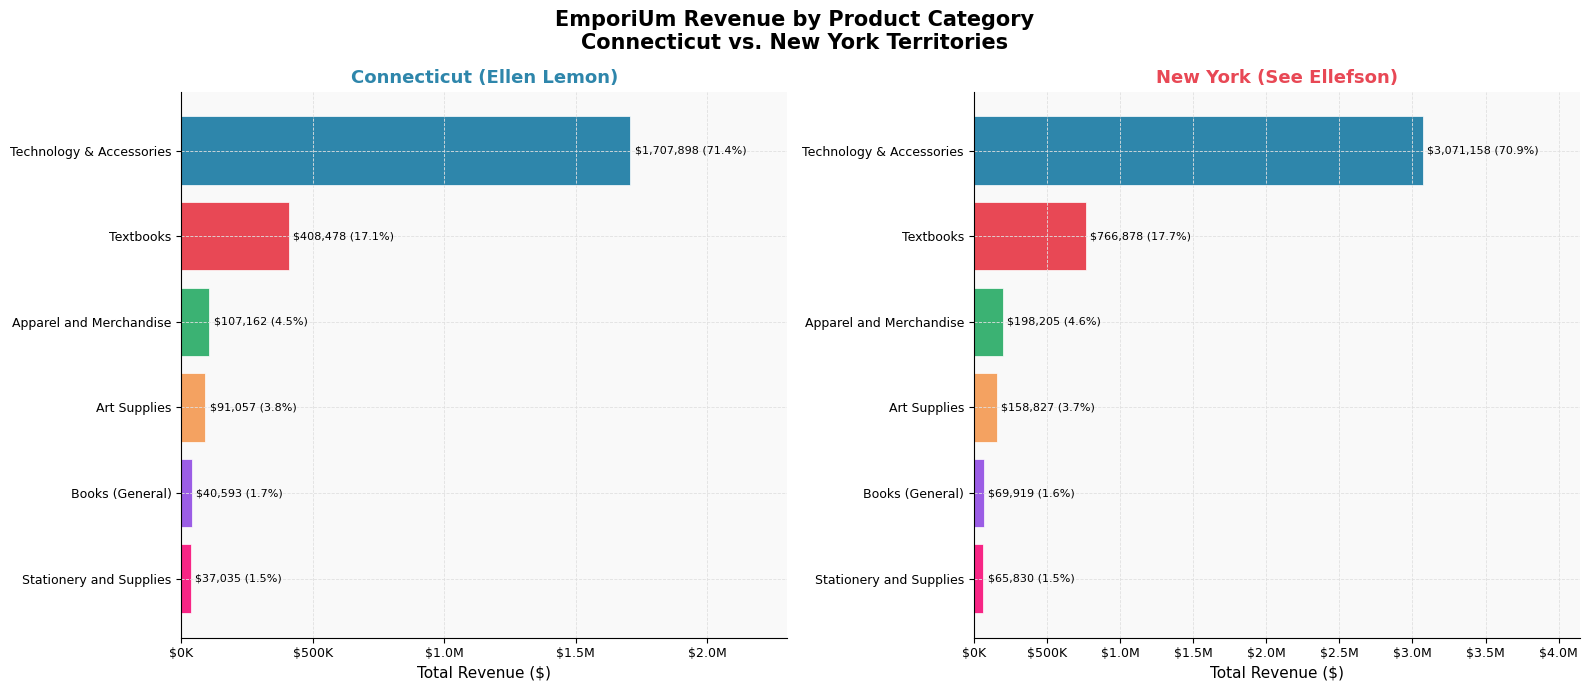

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("EmporiUm Revenue by Product Category\nConnecticut vs. New York Territories",
             fontsize=15, fontweight="bold")

for ax, summary, title, color in [
    (axes[0], ct_cat_summary, "Connecticut (Ellen Lemon)", CT_COLOR),
    (axes[1], ny_cat_summary, "New York (See Ellefson)", NY_COLOR)
]:
    sorted_s = summary.sort_values("total_revenue", ascending=True)
    bars = ax.barh(sorted_s["Category"], sorted_s["total_revenue"],
                   color=CAT_PALETTE[:len(sorted_s)][::-1], edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold", color=color)
    ax.set_xlabel("Total Revenue ($)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M" if x >= 1e6 else f"${x/1000:.0f}K"))
    for bar, val, share in zip(bars, sorted_s["total_revenue"], sorted_s["Revenue Share (%)"]):
        ax.text(bar.get_width() + sorted_s["total_revenue"].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f"${val:,.0f} ({share}%)", va="center", ha="left", fontsize=8)
    ax.set_xlim(0, sorted_s["total_revenue"].max() * 1.35)

plt.tight_layout()
plt.savefig("chart3_category_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


**Key insight:** The category mix is nearly identical across both territories.
Technology dominates at ~71% of revenue in both. However NY's absolute numbers 
are roughly double CT across every category, which is proportional to having 
50% more stores. The most underdeveloped category relative to transaction volume 
in **both** territories is **Stationery & Supplies** highest transaction count 
but lowest revenue and **Apparel**, which has the second most transactions 
but only ~$32 average sale. These are the growth opportunities.

---
### Executive KPI Summary Dashboard

In [101]:
# ── Compute monthly revenue ───────────────────────────────────────────────────
ct_monthly = (ct_sales_df.groupby("Month_Label")["Sale Amount"]
              .sum().reset_index().rename(columns={"Sale Amount": "CT_Revenue"}))
ny_monthly = (ny_sales_df.groupby("Month_Label")["Sale Amount"]
              .sum().reset_index().rename(columns={"Sale Amount": "NY_Revenue"}))

monthly_rev = ct_monthly.merge(ny_monthly, on="Month_Label", how="outer").sort_values("Month_Label")
monthly_rev["Period"] = monthly_rev["Month_Label"].dt.to_timestamp()
monthly_rev["CT_Revenue"] = monthly_rev["CT_Revenue"].fillna(0)
monthly_rev["NY_Revenue"] = monthly_rev["NY_Revenue"].fillna(0)

# ── Compute additional KPIs ────────────────────────────────────────────────────
ct_rewards = ct_sales_df["RewardsID"].notna().sum()
ny_rewards = ny_sales_df["RewardsID"].notna().sum()
ct_rewards_pct = ct_rewards / len(ct_sales_df) * 100
ny_rewards_pct = ny_rewards / len(ny_sales_df) * 100

ct_peak_month = monthly_rev.loc[monthly_rev["CT_Revenue"].idxmax(), ["Period", "CT_Revenue"]]
ny_peak_month = monthly_rev.loc[monthly_rev["NY_Revenue"].idxmax(), ["Period", "NY_Revenue"]]

print("=" * 65)
print(f"{'EmporiUm EAST REGION — KPI EXECUTIVE DASHBOARD':^65}")
print("=" * 65)
print(f"{'Metric':<35} {'Connecticut':>12} {'New York':>12}")
print("-" * 65)
metrics = [
    ("Total Revenue",      f"${total_ct:>10,.0f}", f"${total_ny:>10,.0f}"),
    ("# Stores",           f"{len(CT_STORE_IDS):>12}",   f"{len(NY_STORE_IDS):>12}"),
    ("Avg Revenue/Store",  f"${total_ct/len(CT_STORE_IDS):>10,.0f}", f"${total_ny/len(NY_STORE_IDS):>10,.0f}"),
    ("Total Transactions", f"{len(ct_sales_df):>12,}",  f"{len(ny_sales_df):>12,}"),
    ("Avg Txn Value",      f"${total_ct/len(ct_sales_df):>10,.2f}", f"${total_ny/len(ny_sales_df):>10,.2f}"),
    ("Rewards Txns (%)",   f"{ct_rewards_pct:>11.1f}%", f"{ny_rewards_pct:>11.1f}%"),
    ("Top Category",       "Tech & Access.",            "Tech & Access."),
    ("Peak Revenue Month", ct_peak_month["Period"].strftime("%b %Y"), ny_peak_month["Period"].strftime("%b %Y")),
]
for label, ct_val, ny_val in metrics:
    print(f"{label:<35} {ct_val:>12} {ny_val:>12}")
print("=" * 65)

         EmporiUm EAST REGION — KPI EXECUTIVE DASHBOARD          
Metric                               Connecticut     New York
-----------------------------------------------------------------
Total Revenue                        $ 2,392,222  $ 4,330,817
# Stores                                       8           12
Avg Revenue/Store                    $   299,028  $   360,901
Total Transactions                        17,378       31,039
Avg Txn Value                        $    137.66  $    139.53
Rewards Txns (%)                           10.6%        10.4%
Top Category                        Tech & Access. Tech & Access.
Peak Revenue Month                      Oct 2025     Oct 2025


### Marketing Recommendation — Where to Focus Next Quarter

---

### Rewards Enrollment Drive
The single biggest opportunity across both territories is that 89% of customers
are anonymous.** Only 10.6% of CT transactions and 10.4% of NY transactions are 
linked to a rewards ID. That means out of 48,417 combined transactions, we have 
contact information for only ~5,000.

**Action:** Run a point-of-sale "Sign Up & Save" campaign at all 20 stores next 
quarter. Offer 10% off the current transaction for signing up on the spot. 
Target: double rewards enrollment to 20%+ within 90 days. This unlocks retargeting,
email campaigns, and loyalty data for every future initiative.

### Apparel & Merchandise (High Traffic, Low Spend)
Apparel is the **2nd highest transaction category** in both territories:
- CT: 3,396 transactions but only 32 average sale (107,162 total)
- NY: 6,129 transactions but only 32 average sale (198,205 total)

These customers are walking in — they just aren't spending much per visit. 
Connecticut is surrounded by major universities (Yale, UConn, Quinnipiac, 
Wesleyan); New York has even more (NYU, Columbia, Cornell, RIT, Buffalo).

**Action:** Launch a campus-style "Bundle & Save" promotion — buy any 2 apparel 
items, get 15% off. Time it with fall semester start (August–September). 
Priority stores: New Haven + Bridgeport (CT near Yale), New York + Rochester (NY).
Even lifting average apparel spend from 32 to 45 across existing transaction 
volume would add ~$65,000 in combined territory revenue per year.

### Protect the Technology Revenue Lead
Technology is responsible for **71% of revenue in both territories** — it is the 
entire engine of the business. Laptops alone generated 889,749 in CT and 
approximately $1.6M in NY over 4 years. This category cannot be neglected.

- NY's New York City store ($621,565) and Rochester (607,148) are standout 
  performers — nearly double the next store. These stores drive the territory.
- CT's New London (331,117) and Bridgeport (322,100) lead but with a much 
  tighter spread — all 8 CT stores are within 54,000 of each other.

**Action:** Run a back-to-school tech bundle promotion (laptop + accessories + 
software) in Q3 targeting the August revenue peak visible in both territories. 
For NY, protect New York City and Rochester stores with dedicated tech events. 
For CT, focus on Hartford and New Haven (college-dense cities) to close the gap 
with New London and Bridgeport.